In [2]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
# pobranie i wczytanie danych
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
file_path = os.path.join(path, 'Combined Data.csv')
df = pd.read_csv(file_path)

df = df.drop(columns=['Unnamed: 0'])
df = df.dropna(subset=['statement']).reset_index(drop=True)
total, _ = df.shape
print(f"Pozostało {total:,} przykładów.")

Pozostało 52,681 przykładów.


In [5]:
# podział: tekst do klasyfikacji (X), etykieta (y)
X = df['statement']
y = df['status']

In [6]:
# podział danych na train, validation i test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
    shuffle=True
)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [7]:
def show_distribution(y, name):
    print(f"\n{name} distribution:")
    print((y.value_counts(normalize=True) * 100).round(2))

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")


Train distribution:
status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64

Validation distribution:
status
Normal                  31.02
Depression              29.25
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.26
Stress                   4.91
Personality disorder     2.05
Name: proportion, dtype: float64

Test distribution:
status
Normal                  31.03
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.28
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64


In [8]:
# podstawowy preprocessing: lowercase + whitespace cleanup
def preprocess(text):
    text = text.lower()
    text = ' '.join(text.split())
    return text

X_train_base = X_train.apply(preprocess)
X_val_base = X_val.apply(preprocess)
X_test_base = X_test.apply(preprocess)

In [9]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])
baseline.fit(X_train_base, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('log_reg', LogisticRegression(max_iter=1000))])

In [10]:
y_val_pred = baseline.predict(X_val_base)
f1_macro = f1_score(y_val, y_val_pred, average='macro')

print(classification_report(y_val, y_val_pred))
print(f"F1 macro: {f1_macro:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.82      0.70      0.76       576
             Bipolar       0.88      0.62      0.72       416
          Depression       0.69      0.75      0.72      2311
              Normal       0.86      0.95      0.90      2451
Personality disorder       0.88      0.46      0.61       162
              Stress       0.64      0.44      0.52       388
            Suicidal       0.70      0.67      0.68      1598

            accuracy                           0.76      7902
           macro avg       0.78      0.65      0.70      7902
        weighted avg       0.76      0.76      0.76      7902

F1 macro: 0.70


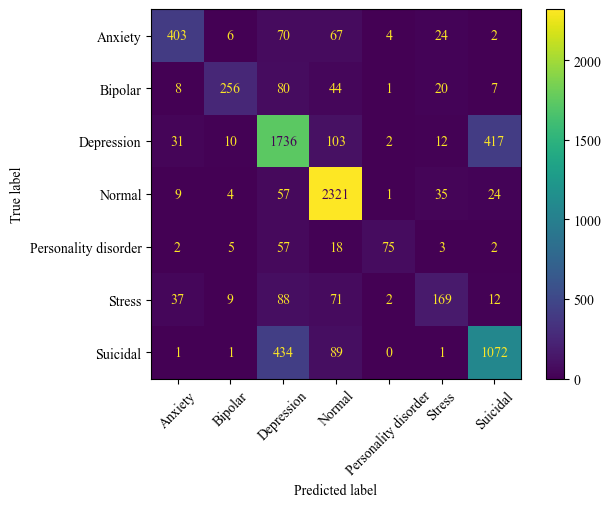

In [11]:
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    xticks_rotation=45)